In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/bank_project/1_bank_customers_churn_dataset.csv')
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [3]:
# 1. نتأكد هل فيه قيم مفقودة (فاضية) بأي عمود
# لو النتيجة صفر بكل الأعمدة، معناها ما فيه بيانات ناقصة
print("عدد القيم المفقودة بكل عمود:")
print(df.isnull().sum())

# 2. نتأكد هل فيه صفوف مكررة بالكامل (نفس العميل انكتب مرتين غلط مثلاً)
print("\nعدد الصفوف المكررة:", df.duplicated().sum())

# 3. نشوف توزيع العمود المستهدف (Attrition_Flag) - هذا أهم عمود بمشروعنا
# لأنه يوضح لنا كم عميل غادر البنك وكم لسا عميل
print("\nتوزيع حالة العميل (غادر / لسا عميل):")
print(df['Attrition_Flag'].value_counts())

عدد القيم المفقودة بكل عمود:
CLIENTNUM                   0
Attrition_Flag              0
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Avg_Open_To_Buy             0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
dtype: int64

عدد الصفوف المكررة: 0

توزيع حالة العميل (غادر / لسا عميل):
Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64


In [4]:
# نحسب متوسط كل متغير مهم لكل فئة (مستمر / مغادر) عشان نقارن بينهم
# الأعمدة اللي اخترناها هي أهم مؤشرات سلوك مالي بالبيانات
key_vars = ['Total_Trans_Ct', 'Total_Trans_Amt', 'Contacts_Count_12_mon',
            'Months_Inactive_12_mon', 'Avg_Utilization_Ratio']

# groupby يقسم البيانات لمجموعتين (مستمر / مغادر) ويحسب المتوسط لكل مجموعة لحالها
comparison = df.groupby('Attrition_Flag')[key_vars].mean().round(2)

# نطبعها كجدول عشان تبين واضحة
print(comparison)

                   Total_Trans_Ct  Total_Trans_Amt  Contacts_Count_12_mon  \
Attrition_Flag                                                              
Attrited Customer           44.93          3095.03                   2.97   
Existing Customer           68.67          4654.66                   2.36   

                   Months_Inactive_12_mon  Avg_Utilization_Ratio  
Attrition_Flag                                                    
Attrited Customer                    2.69                   0.16  
Existing Customer                    2.27                   0.30  


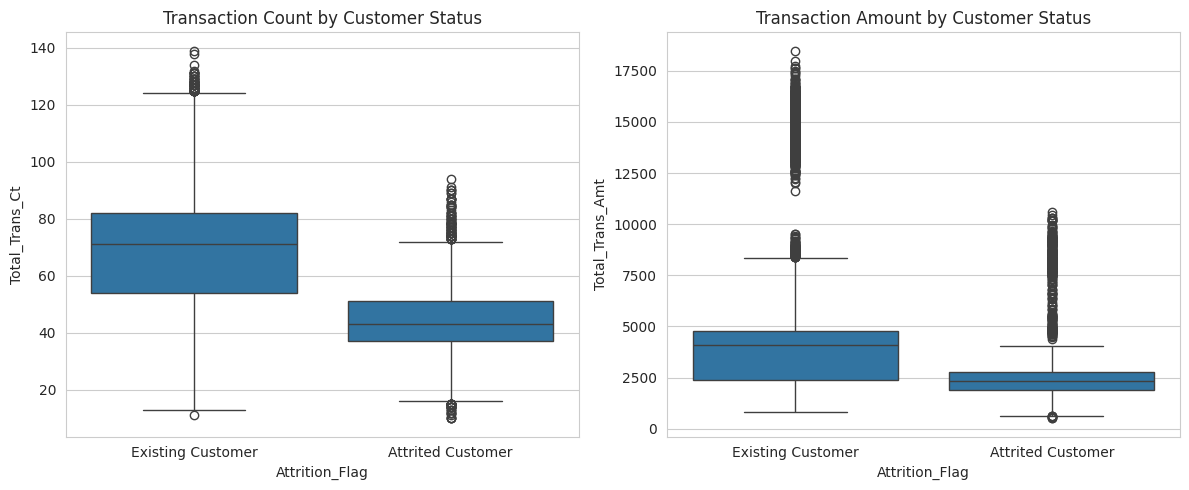

In [5]:
# نستدعي مكتبة الرسم البياني
import matplotlib.pyplot as plt
import seaborn as sns

# نحدد شكل عام أنيق للرسومات
sns.set_style("whitegrid")

# نسوي رسمتين جنب بعض: وحدة لعدد المعاملات، وحدة للمبلغ
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# الرسمة الأولى: صندوق (Boxplot) يوضح توزيع عدد المعاملات لكل فئة
sns.boxplot(data=df, x='Attrition_Flag', y='Total_Trans_Ct', ax=axes[0])
axes[0].set_title('Transaction Count by Customer Status')  # عنوان الرسمة بالإنجليزي (معيار احترافي بالمشاريع)

# الرسمة الثانية: نفس الشي بس لمبلغ المعاملات
sns.boxplot(data=df, x='Attrition_Flag', y='Total_Trans_Amt', ax=axes[1])
axes[1].set_title('Transaction Amount by Customer Status')

# نعرض الرسمتين
plt.tight_layout()  # يرتب المسافات عشان ما يتزاحمون
plt.show()

In [6]:
# نحسب معدل المغادرة (كنسبة مئوية) لكل فئة عمرية
# أول شي نقسم العمر لفئات (Bins) عشان يكون التحليل أوضح من عمر مفرد مفرد
df['Age_Group'] = pd.cut(df['Customer_Age'],
                          bins=[18, 30, 40, 50, 60, 100],
                          labels=['18-30', '31-40', '41-50', '51-60', '60+'])

# ننشئ عمود رقمي مؤقت: 1 لو العميل غادر، 0 لو لسا مستمر
# هذا يسهل علينا حساب "المعدل" (النسبة) مباشرة بدالة mean()
df['Churn_Flag'] = (df['Attrition_Flag'] == 'Attrited Customer').astype(int)

# نحسب معدل المغادرة لكل فئة عمرية (متوسط Churn_Flag = نسبة المغادرين)
age_churn = df.groupby('Age_Group', observed=True)['Churn_Flag'].mean() * 100
print("معدل المغادرة % حسب الفئة العمرية:")
print(age_churn.round(1))

# نفس الشي بس لفئة الدخل
income_churn = df.groupby('Income_Category', observed=True)['Churn_Flag'].mean() * 100
print("\nمعدل المغادرة % حسب فئة الدخل:")
print(income_churn.round(1))

معدل المغادرة % حسب الفئة العمرية:
Age_Group
18-30    12.1
31-40    14.5
41-50    16.7
51-60    16.8
60+      14.3
Name: Churn_Flag, dtype: float64

معدل المغادرة % حسب فئة الدخل:
Income_Category
$120K +           17.3
$40K - $60K       15.1
$60K - $80K       13.5
$80K - $120K      15.8
Less than $40K    17.2
Unknown           16.8
Name: Churn_Flag, dtype: float64


In [7]:
# نحسب معدل المغادرة حسب عدد المنتجات البنكية اللي عند العميل
# (Total_Relationship_Count = كم منتج عنده: بطاقة، حساب توفير، قرض...الخ)
relationship_churn = df.groupby('Total_Relationship_Count', observed=True)['Churn_Flag'].mean() * 100
print("معدل المغادرة % حسب عدد المنتجات البنكية:")
print(relationship_churn.round(1))

# نفس الفكرة بس حسب نوع البطاقة (Blue, Silver, Gold, Platinum)
card_churn = df.groupby('Card_Category', observed=True)['Churn_Flag'].mean() * 100
print("\nمعدل المغادرة % حسب نوع البطاقة:")
print(card_churn.round(1))

معدل المغادرة % حسب عدد المنتجات البنكية:
Total_Relationship_Count
1    25.6
2    27.8
3    17.4
4    11.8
5    12.0
6    10.5
Name: Churn_Flag, dtype: float64

معدل المغادرة % حسب نوع البطاقة:
Card_Category
Blue        16.1
Gold        18.1
Platinum    25.0
Silver      14.8
Name: Churn_Flag, dtype: float64


In [8]:
# نحمّل داتا ست الاحتيال بنفس طريقة الملف الأول، بس نسميه fraud_df
# عشان ما يتعارض مع df (ملف العملاء) اللي شغالين عليه من قبل
fraud_df = pd.read_csv('/content/drive/MyDrive/bank_project/2_fraud_transactions_dataset.csv')

# نشوف أول 5 صفوف عشان نتأكد اتحمل صح ونفهم شكله
fraud_df.head()

,transaction_id,CLIENTNUM,transaction_datetime,amount,merchant_category,hour_of_day,is_foreign_transaction,distance_from_home_km,is_fraud
0,1,719455083,2024-05-31 07:00:00,41.94,Travel,7,0,2.5,0
1,2,719455083,2024-08-04 20:00:00,79.49,ATM Withdrawal,20,0,18.5,0
2,3,719455083,2024-04-23 20:00:00,44.02,ATM Withdrawal,20,0,14.2,0
3,4,719455083,2024-04-05 09:00:00,80.79,Grocery,9,0,54.6,0
4,5,719455083,2024-02-07 02:00:00,63.55,Gas Station,2,0,17.1,0


In [9]:
# نشوف الشكل العام: كم صف وكم عمود
print("عدد المعاملات والأعمدة:", fraud_df.shape)

# نتأكد ما فيه قيم مفقودة
print("\nعدد القيم المفقودة بكل عمود:")
print(fraud_df.isnull().sum())

# أهم رقم بهالملف: توزيع الاحتيال (كم معاملة احتيال وكم سليمة)
print("\nتوزيع المعاملات (احتيال=1 / سليمة=0):")
print(fraud_df['is_fraud'].value_counts())

# نفس الشي بس كنسبة مئوية، عشان نفهم حجم المشكلة بوضوح
fraud_rate = fraud_df['is_fraud'].mean() * 100
print(f"\nنسبة الاحتيال: {fraud_rate:.2f}%")

عدد المعاملات والأعمدة: (31201, 9)

عدد القيم المفقودة بكل عمود:
transaction_id            0
CLIENTNUM                 0
transaction_datetime      0
amount                    0
merchant_category         0
hour_of_day               0
is_foreign_transaction    0
distance_from_home_km     0
is_fraud                  0
dtype: int64

توزيع المعاملات (احتيال=1 / سليمة=0):
is_fraud
0    30395
1      806
Name: count, dtype: int64

نسبة الاحتيال: 2.58%


In [10]:
# نقارن متوسط المبلغ والمسافة من المنزل بين المعاملات السليمة والاحتيال
comparison_vars = ['amount', 'distance_from_home_km', 'hour_of_day', 'is_foreign_transaction']

fraud_comparison = fraud_df.groupby('is_fraud')[comparison_vars].mean().round(2)
print("مقارنة: معاملة سليمة (0) مقابل احتيال (1)")
print(fraud_comparison)

# كمان نشوف نسبة الاحتيال حسب نوع المتجر (Merchant Category)
# هذا يوضح لنا هل فيه فئات متاجر أخطر من غيرها
merchant_fraud = fraud_df.groupby('merchant_category')['is_fraud'].mean() * 100
print("\nنسبة الاحتيال % حسب نوع المتجر:")
print(merchant_fraud.round(2).sort_values(ascending=False))

مقارنة: معاملة سليمة (0) مقابل احتيال (1)
          amount  distance_from_home_km  hour_of_day  is_foreign_transaction
is_fraud                                                                    
0          81.39                  49.07        11.60                    0.04
1          86.32                 275.45         8.26                    0.31

نسبة الاحتيال % حسب نوع المتجر:
merchant_category
Jewelry           6.55
Electronics       5.13
Online Retail     3.64
Travel            2.53
ATM Withdrawal    1.55
Restaurant        1.03
Gas Station       0.98
Utility Bill      0.91
Grocery           0.90
Name: is_fraud, dtype: float64


In [11]:
# الخطوة 1: نلخص داتا ست الاحتيال على مستوى كل عميل (مو كل معاملة)
# نبي نعرف: كل عميل، هل صارت له معاملة احتيال ولو مرة وحدة؟ وكم مرة بالضبط؟
customer_fraud_summary = fraud_df.groupby('CLIENTNUM').agg(
    total_transactions=('transaction_id', 'count'),   # كم معاملة عنده إجمالي
    fraud_count=('is_fraud', 'sum'),                    # كم مرة انصار له احتيال
).reset_index()

# نسوي عمود يبين هل تعرض لاحتيال ولو مرة (نعم/لا) - أسهل للتحليل
customer_fraud_summary['was_fraud_victim'] = (customer_fraud_summary['fraud_count'] > 0).astype(int)

print("ملخص الاحتيال لكل عميل (أول 5 صفوف):")
print(customer_fraud_summary.head())

# الخطوة 2: ندمج (Merge) هذا الملخص مع ملف العملاء الأصلي (df)
# نستخدم CLIENTNUM كـ"مفتاح الربط" - نفس الرقم موجود بالملفين
merged_df = df.merge(customer_fraud_summary, on='CLIENTNUM', how='left')

# بعض العملاء بملف العملاء ما عندهم معاملات بملف الاحتيال أصلاً (لأننا أخذنا عينة 2000 بس)
# فنعبي القيم الفاضية بصفر (يعني ما تعرضوا لاحتيال لأنه ما عندهم بيانات معاملات أصلاً)
merged_df['was_fraud_victim'] = merged_df['was_fraud_victim'].fillna(0).astype(int)

print("\nعدد العملاء بعد الدمج:", merged_df.shape[0])
print("عدد العملاء اللي عندهم بيانات معاملات:", merged_df['fraud_count'].notna().sum())

ملخص الاحتيال لكل عميل (أول 5 صفوف):
   CLIENTNUM  total_transactions  fraud_count  was_fraud_victim
0  708095133                   7            0                 0
1  708112008                   8            1                 1
2  708152358                  14            0                 0
3  708160008                  21            1                 1
4  708170508                  10            0                 0

عدد العملاء بعد الدمج: 10127
عدد العملاء اللي عندهم بيانات معاملات: 2000


In [12]:
# نفلتر بس العملاء اللي فعليًا عندهم بيانات معاملات (يعني fraud_count مو فاضي)
# هذا مهم جدًا عشان المقارنة تكون عادلة ومنطقية
valid_customers = merged_df[merged_df['fraud_count'].notna()].copy()

print("عدد العملاء اللي بنقارن بينهم:", valid_customers.shape[0])

# نحسب معدل المغادرة لكل مجموعة: تعرض لاحتيال (1) مقابل ما تعرض (0)
fraud_churn_comparison = valid_customers.groupby('was_fraud_victim')['Churn_Flag'].mean() * 100
print("\nمعدل المغادرة % حسب التعرض للاحتيال:")
print(fraud_churn_comparison.round(1))

# كمان نشوف كم عميل بكل مجموعة (عشان نتأكد العينة كافية زي ما تعلمنا)
print("\nعدد العملاء بكل مجموعة:")
print(valid_customers['was_fraud_victim'].value_counts())

عدد العملاء اللي بنقارن بينهم: 2000

معدل المغادرة % حسب التعرض للاحتيال:
was_fraud_victim
0    17.3
1    13.5
Name: Churn_Flag, dtype: float64

عدد العملاء بكل مجموعة:
was_fraud_victim
0    1347
1     653
Name: count, dtype: int64
